# Eigenvalue Analysis Demo

Demonstration of `eigenvalue_analysis.py` module usage.


In [1]:
import numpy as np
import matplotlib.pyplot as plt
import eigenvalue_analysis as eva


## ISW Accuracy Analysis


In [2]:
# Analyze first 5 eigenvalues with 201 grid points
results = eva.analyze_ISW_accuracy(n_eigenvalues=5, n_grid_points=201, order=4)

print(f"Grid spacing: dx = {results['grid_spacing']:.6f}\n")
print(f"{'Level':<8} {'Analytical':<12} {'Numerical':<12} {'Abs Error':<12} {'Rel Error':<12}")
print("-" * 60)
for i in range(5):
    print(f"{i+1:<8} {results['analytical'][i]:<12.6f} "
          f"{results['numerical'][i]:<12.6f} "
          f"{results['absolute_errors'][i]:<12.2e} "
          f"{results['relative_errors'][i]:<12.2e}")


Grid spacing: dx = 0.004950

Level    Analytical   Numerical    Abs Error    Rel Error   
------------------------------------------------------------
1        4.934802     4.934802     3.76e-09     7.62e-10    
2        19.739209    19.739209    2.41e-07     1.22e-08    
3        44.413220    44.413217    2.74e-06     6.17e-08    
4        78.956835    78.956820    1.54e-05     1.95e-07    
5        123.370055   123.369996   5.87e-05     4.76e-07    


## QSHO Accuracy Analysis


In [3]:
# Analyze first 5 eigenvalues with 201 grid points
results = eva.analyze_QSHO_accuracy(n_eigenvalues=5, n_grid_points=201, order=4)

print(f"Grid spacing: dx = {results['grid_spacing']:.6f}")
print(f"Domain: [{results['domain'][0]:.2f}, {results['domain'][1]:.2f}]\n")
print(f"{'Level':<8} {'Analytical':<12} {'Numerical':<12} {'Abs Error':<12} {'Rel Error':<12}")
print("-" * 60)
for i in range(5):
    print(f"{i:<8} {results['analytical'][i]:<12.6f} "
          f"{results['numerical'][i]:<12.6f} "
          f"{results['absolute_errors'][i]:<12.2e} "
          f"{results['relative_errors'][i]:<12.2e}")


Grid spacing: dx = 0.108911
Domain: [-11.00, 11.00]

Level    Analytical   Numerical    Abs Error    Rel Error   
------------------------------------------------------------
0        0.500000     0.499999     1.46e-06     2.92e-06    
1        1.500000     1.499990     1.02e-05     6.81e-06    
2        2.500000     2.499964     3.64e-05     1.46e-05    
3        3.500000     3.499908     9.16e-05     2.62e-05    
4        4.500000     4.499813     1.87e-04     4.16e-05    


## Convergence Study


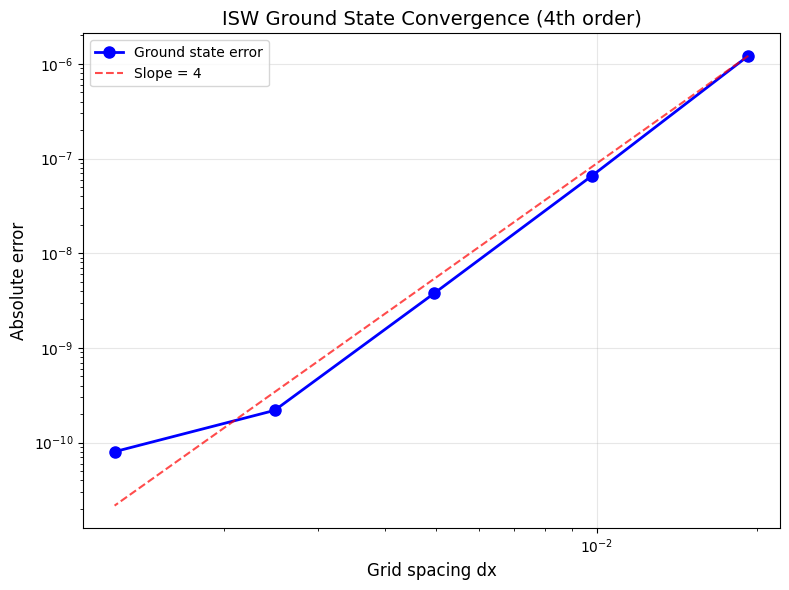


Convergence rate: 3.65 (expected: 4.0)


In [4]:
# Study convergence for ISW ground state
grid_points = [51, 101, 201, 401, 801]
conv = eva.convergence_study_ISW(n_eigenvalues=1, grid_points_list=grid_points, order=4)

# Plot log-log convergence
plt.figure(figsize=(8, 6))
plt.loglog(conv['grid_spacings'], conv['absolute_errors'][:, 0], 'bo-', 
           linewidth=2, markersize=8, label='Ground state error')

# Add reference slope
x_ref = np.array([conv['grid_spacings'][0], conv['grid_spacings'][-1]])
y_ref = conv['absolute_errors'][0, 0] * (x_ref / conv['grid_spacings'][0])**4
plt.loglog(x_ref, y_ref, 'r--', alpha=0.7, label='Slope = 4')

plt.xlabel('Grid spacing dx', fontsize=12)
plt.ylabel('Absolute error', fontsize=12)
plt.title('ISW Ground State Convergence (4th order)', fontsize=14)
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Calculate convergence rate
log_dx = np.log(conv['grid_spacings'])
log_err = np.log(conv['absolute_errors'][:, 0])
rate = np.polyfit(log_dx, log_err, 1)[0]
print(f"\nConvergence rate: {rate:.2f} (expected: 4.0)")


## Comparing 2nd vs 4th Order Methods


In [5]:
# Compare methods for same problem
results_2nd = eva.analyze_QSHO_accuracy(n_eigenvalues=5, n_grid_points=201, order=2)
results_4th = eva.analyze_QSHO_accuracy(n_eigenvalues=5, n_grid_points=201, order=4)

print("QSHO Absolute Errors Comparison (N=201):\n")
print(f"{'Level':<8} {'2nd Order':<15} {'4th Order':<15} {'Improvement':<15}")
print("-" * 60)
for i in range(5):
    improvement = results_2nd['absolute_errors'][i] / results_4th['absolute_errors'][i]
    print(f"{i:<8} {results_2nd['absolute_errors'][i]:<15.2e} "
          f"{results_4th['absolute_errors'][i]:<15.2e} "
          f"{improvement:<15.1f}x")


QSHO Absolute Errors Comparison (N=201):

Level    2nd Order       4th Order       Improvement    
------------------------------------------------------------
0        5.11e+00        1.46e-06        3501915.6      x
1        6.06e+00        1.02e-05        593950.1       x
2        6.90e+00        3.64e-05        189509.4       x
3        7.73e+00        9.16e-05        84294.4        x
4        8.65e+00        1.87e-04        46160.6        x
